# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [ ]:
import pandas as pd

Load our cleaned DataFrames

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/102LzPJyIz4t6ebITHhjxQOvdv-0zBiju/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1e_7_Hrv2hMnu_yQ-KkZpOX0n5s7HSiMc/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1yb_9rQWDTy3bYWpr4cXOhMPIixRTVjNm/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1_JJj8BVRWyXVUZyA4CSyooWqKKdaAUKc/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_cl = pd.read_csv(path)

In [ ]:
orders_cl["created_date"] = pd.to_datetime(orders_cl["created_date"])

## 1.&nbsp; Define Pandas display format

In [ ]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 2)# how many decimals to show
pd.set_option('display.float_format', lambda x: '%.2f' % x)

``` Let's do some Data Analysis```


In [ ]:
orders_qa = orders_cl.copy()
orderlines_qa = orderlines_cl.copy()
products_qa = products_cl.copy()

In [ ]:
# your code here
orders_qa

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled
...,...,...,...,...
226899,527397,2018-03-14 13:56:38,42.99,Place Order
226900,527398,2018-03-14 13:57:25,42.99,Shopping Basket
226901,527399,2018-03-14 13:57:34,141.58,Shopping Basket
226902,527400,2018-03-14 13:57:41,19.98,Shopping Basket


In [ ]:
orderlines_qa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                293983 non-null  int64  
 1   id_order          293983 non-null  int64  
 2   product_id        293983 non-null  int64  
 3   product_quantity  293983 non-null  int64  
 4   sku               293983 non-null  object 
 5   unit_price        293983 non-null  float64
 6   date              293983 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 15.7+ MB


In [ ]:
orders_qa.groupby('state')['order_id'].count()
#alternative
#orders_qa.state.value_counts()

,order_id
state,
Cancelled,7233
Completed,46605
Pending,14374
Place Order,40883
Shopping Basket,117809


## 2.&nbsp; Exclude unwanted orders

we would like to focus on the 'Completed' orders

In [ ]:
# orders_qa = orders_qa[orders_qa['state'] != 'Cancelled']
#alternative
# orders_qa = orders_qa[~orders_cl['state'].isin(['Cancelled', 'Shopping basket'])]
orders_qa = orders_qa.loc[orders_qa['state'].isin(['Completed']), :]

In [ ]:
orders_qa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46605 entries, 1 to 226614
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      46605 non-null  int64         
 1   created_date  46605 non-null  datetime64[ns]
 2   total_paid    46605 non-null  float64       
 3   state         46605 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.8+ MB


In [ ]:
orders_qa.order_id.nunique()

46605

In [ ]:
orderlines_qa.id_order.nunique()

204855

What a huge difference! We want to make sure that every order_id in orders also exists in orderlines and vice versa.

Hence we'll perform an inner merge on the two tables using the order_id & id_order. This will then keep only the order_id's that are present in both tables, which will then help us filter our _qa DataFrames once again.

In [ ]:
orders_orderlines = orders_qa.merge(orderlines_qa, how="inner", left_on="order_id", right_on="id_order")

In [ ]:
orders_orderlines["order_id"].nunique()

46560

In [ ]:
# order_ids that are in both tables
order_ids = orders_orderlines["order_id"].unique()

In [ ]:
order_ids

array([241423, 242832, 243330, ..., 527074, 527096, 527112])

In [ ]:
# keep those ids in orders
orders_qa = orders_qa.loc[orders_qa["order_id"].isin(order_ids), :]

# keep those ids in orderlines
orderlines_qa = orderlines_qa.loc[orderlines_qa["id_order"].isin(order_ids), :]

Let's have a quick check to make sure we're filtering both DataFrames the same. They should both contain the same number of unique order_id's.

In [ ]:
orders_qa["order_id"].nunique(),orderlines_qa["id_order"].nunique()

(46560, 46560)

## 3.&nbsp; Exclude orders with unknown products


Let's start by investigating `orderlines` and `products`. We want to make sure that every product in `orderlines` has a matching entry in `products`. All orders with a missing product need to be removed from both `orderlines` and `orders`.

A left-join can help us here:

Joining `orderlines` left on `products` will keep all orderlines, and add the information of `products` on the matching skus. If an sku has been sold in `orderlines`, but the sku does not have an entry in `products` then the product_name will be empty.

In [ ]:
orderlines_qa

,id,id_order,product_id,product_quantity,sku,unit_price,date
7,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16
8,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34
9,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11
11,1119126,299549,0,1,PAC0929,2565.99,2017-01-01 02:07:42
18,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14
...,...,...,...,...,...,...,...
293599,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05
293616,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
293621,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
293644,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


In [ ]:
#cheking unit_price with zero value
orderlines_qa.loc[(orderlines_qa['unit_price'] ==0)].count()

,0
id,49
id_order,49
product_id,49
product_quantity,49
sku,49
unit_price,49
date,49


In [ ]:
orderlines_qa.nlargest(10,'unit_price')

,id,id_order,product_id,product_quantity,sku,unit_price,date
170927,1451975,445507,0,1,LAC0223,8287.80,2017-11-26 16:02:50
122992,1363612,405497,0,1,PAC2159,7335.59,2017-09-27 17:17:22
249181,1579003,497912,0,1,PAC2159,7261.59,2018-01-24 20:44:49
252832,1584686,499436,0,1,APP2677,5917.00,2018-01-28 15:34:51
43394,1209428,337292,0,1,PAC0499,5411.99,2017-03-21 03:53:42
158226,1430849,435467,0,1,PAC2154,5304.59,2017-11-23 22:17:27
101807,1313259,387179,0,1,PAC2149,5236.59,2017-08-07 18:33:33
259495,1595428,504010,0,1,APP2637,5230.64,2018-02-01 22:13:45
271810,1614552,511836,0,1,APP2637,5230.64,2018-02-15 00:18:52
279199,1627085,517407,0,1,APP2637,5229.00,2018-02-25 23:52:41


In [ ]:
orderlines_qa.nsmallest(10,'unit_price')

,id,id_order,product_id,product_quantity,sku,unit_price,date
56743,1233198,348684,0,1,LIBRO,0.00,2017-04-22 13:17:11
56974,1233563,348874,0,1,LIBRO,0.00,2017-04-23 12:16:01
57001,1233609,348891,0,1,LIBRO,0.00,2017-04-23 13:17:55
57133,1233835,348998,0,1,LIBRO,0.00,2017-04-23 21:40:08
57185,1233924,349041,0,2,LIBRO,0.00,2017-04-23 23:31:56
57310,1234115,349136,0,1,LIBRO,0.00,2017-04-24 10:24:58
57313,1234121,349139,0,1,LIBRO,0.00,2017-04-24 10:41:59
57386,1234242,349187,0,1,LIBRO,0.00,2017-04-24 12:36:18
57563,1234538,349315,0,1,LIBRO,0.00,2017-04-24 18:02:19
57912,1235107,349563,0,1,LIBRO,0.00,2017-04-25 13:01:26


In [ ]:
#dropping the unite_price with zero values as there are no negative values
orderlines_qa= orderlines_qa.loc[orderlines_qa['unit_price']!=0]

In [ ]:
orderlines_qa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62054 entries, 7 to 293661
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                62054 non-null  int64  
 1   id_order          62054 non-null  int64  
 2   product_id        62054 non-null  int64  
 3   product_quantity  62054 non-null  int64  
 4   sku               62054 non-null  object 
 5   unit_price        62054 non-null  float64
 6   date              62054 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 3.8+ MB


In [ ]:
orderlines_qa.isna().sum()

,0
id,0
id_order,0
product_id,0
product_quantity,0
sku,0
unit_price,0
date,0


In [ ]:
# We don't really need product_id, so drop it
orderlines_qa.drop(columns='product_id',inplace=True)

/tmp/ipykernel_52369/3689409917.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orderlines_qa.drop(columns='product_id',inplace=True)


In [ ]:
# just in case if there is any word 'unknown'
mask = orderlines_qa.apply(lambda col: col.astype(str).str.contains('unknown', case=False))
orderlines_qa[mask.any(axis=1)].sum()


,0
id,0
id_order,0
product_quantity,0
sku,0
unit_price,0.00
date,0


## 4.&nbsp; Explore the revenue from different tables

The products table is the official catalog
It contains the true list of all products company sells.
✔ The orderlines table is just a list of what customers tried to buy
But orderlines can contain:
• typos
• discontinued SKUs
• corrupted SKUs
• SKUs that never existed
• SKUs missing from the product catalog
So orderlines cannot be trusted as the source of truth. That is why valid SKUs must come from the products table, not the orderlines table

As for an example
Products table = the menu,
Orderlines table = what customers ordered.
If a customer ordered something not on the menu, you remove that line.
You don't change the menu to match the order — you clean the order to match the menu.

In [ ]:
products_qa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   object 
 1   name      9992 non-null   object 
 2   desc      9992 non-null   object 
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9946 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 468.5+ KB


In a consistent and coherent dataset the value of an order should roughly match the sum of all items bought on that order. Let's investigate...

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [ ]:
orders_qa_copy = orders_qa.copy()
orderlines_qa_copy = orderlines_qa.copy()

In [ ]:
orderlines_qa_copy['unit_price_total']=orderlines_qa_copy['unit_price']*orderlines_qa_copy['product_quantity']

In [ ]:
orderlines_qa_copy.head()

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total
7,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
8,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
9,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19
11,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,2565.99
18,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [ ]:
orderlines_order_ids = orderlines_qa_copy.groupby('id_order', as_index=False)['unit_price_total'].sum()
# orderlines_order_ids = orderlines_qa_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()
# as_index=False changes the return so that the groupedby column remains a column (not the index)

In [ ]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
46555,527042,13.99
46556,527070,19.98
46557,527074,19.98
46558,527096,29.97


### What is the average difference between `total_paid` and `unit_price_total`?

In [ ]:
diff_df = orders_qa_copy.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")

In [ ]:
diff_df

,order_id,created_date,total_paid,state,id_order,unit_price_total
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98
...,...,...,...,...,...,...
46555,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99
46556,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98
46557,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98
46558,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97


In [ ]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246018,2017-02-13 23:02:57,211.95,Completed,246018,206.96,4.99
6,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
7,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
8,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
9,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99


In [ ]:
diff_df.nsmallest(10, 'difference')

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
26475,432303,2017-11-22 21:43:02,261.86,Completed,432303,426.86,-165.00
86,289685,2017-01-09 23:15:07,15.95,Completed,289685,135.97,-120.02
5608,319901,2017-02-04 16:09:34,60.43,Completed,319901,142.44,-82.01
352,300474,2017-01-02 12:24:54,119.00,Completed,300474,164.90,-45.90
4129,314570,2017-01-25 09:01:35,122.99,Completed,314570,164.90,-41.91
7385,327363,2017-02-21 22:42:17,122.99,Completed,327363,164.90,-41.91
2533,308825,2017-01-13 14:27:46,123.99,Completed,308825,164.90,-40.91
3474,312311,2017-01-20 00:59:54,125.99,Completed,312311,164.90,-38.91
6147,322147,2017-02-10 11:56:59,125.99,Completed,322147,164.90,-38.91
1982,306927,2017-01-10 23:18:53,130.99,Completed,306927,164.90,-33.91


In [ ]:
diff_df.nlargest(10, 'difference')

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
110,297148,2017-01-01 16:42:24,4069.54,Completed,297148,84.55,3984.99
93,293308,2017-01-01 13:33:43,2635.47,Completed,293308,66.49,2568.98
43742,512894,2018-02-16 13:25:30,3356.18,Completed,512894,1674.60,1681.58
42780,508825,2018-02-16 11:21:44,2590.18,Completed,508825,1291.60,1298.58
43847,513447,2018-02-17 19:26:59,486.89,Completed,513447,94.98,391.91
43770,513009,2018-02-16 17:33:09,406.80,Completed,513009,20.00,386.80
43548,512146,2018-02-15 17:32:17,632.98,Completed,512146,313.00,319.98
42950,509673,2018-02-17 16:25:44,2708.97,Completed,509673,2408.99,299.98
43775,513049,2018-02-16 19:03:22,504.98,Completed,513049,249.00,255.98
43759,512969,2018-02-16 15:48:22,376.96,Completed,512969,123.99,252.97


In [ ]:
diff_df.difference.mean().round(2)

np.float64(4.24)

### What is the distribution of these differences?

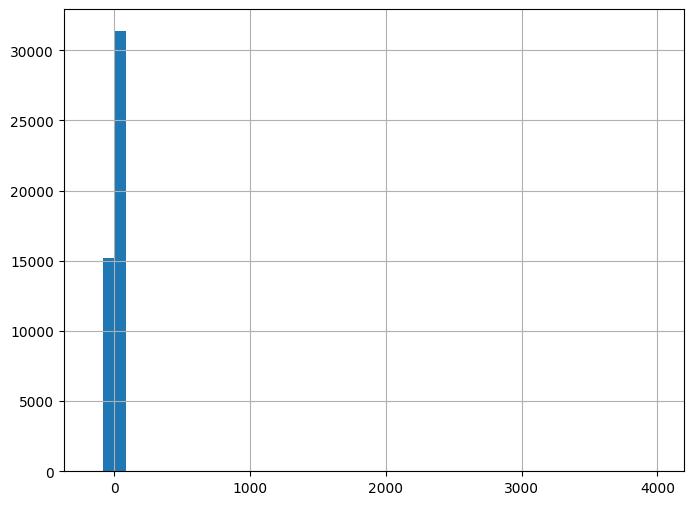

In [ ]:
diff_df.difference.hist(bins= 50, figsize=(8,6));

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

Looking at the spread of the data above, some of the difference must be due to corruption. Let's use .describe() to investigate the distribution further.


In [ ]:
diff_df.difference.describe()

,difference
count,46560.00
mean,4.24
std,24.72
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


### If there are differences that you can’t explain: what should you do with these orders?

We can see from the our quartiles (0.00, 4.99, 6.99) that most of our data fits an expected pattern - free, 4.99, and 6.99 all seem like reasonable prices to assume as postage. However, look at the min and the max values, -165.00 and 3984.99, this can only occur due to corrupted data.

There's a rule of thumb, that anything:

lower than the 25% quartile - (1.5 x interquartile range), or
higher than the 75% quartile + (1.5 x interquartile range)
is an outlier. Let's use this rule to try and exclude any corrupted data.

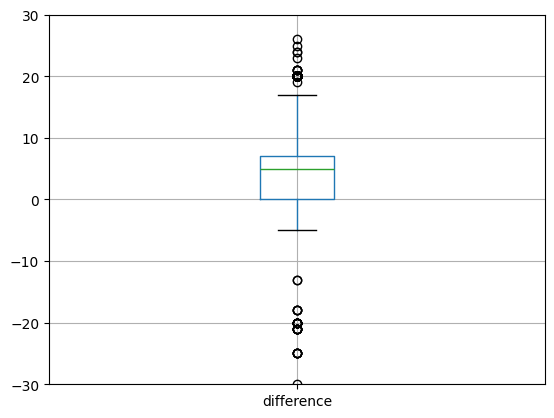

In [ ]:
# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = diff_df.boxplot("difference");
ax.set_ylim(-30, +30)
plt.show()

In [ ]:
# calculate the quartiles
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)

Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [ ]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [ ]:
# lower boundary
lower = Q1 - 1.5*IQR
lower

np.float64(-10.484999999999971)

In [ ]:
# upper boundary
upper = Q3 + 1.5*IQR
upper

np.float64(17.47499999999995)

Identify which rows are outliers

In [ ]:
outliers = diff_df[(diff_df['difference'] < lower) | (diff_df['difference'] > upper)]
outliers

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
6,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
11,251688,2017-11-24 23:57:07,505.76,Completed,251688,485.77,19.99
12,251969,2017-11-21 21:04:12,610.07,Completed,251969,590.08,19.99
14,253306,2017-10-04 14:14:45,497.68,Completed,253306,477.68,20.00
40,264244,2018-01-29 15:33:06,141.97,Completed,264244,69.99,71.98
...,...,...,...,...,...,...,...
46286,525664,2018-03-14 11:56:19,85.73,Completed,525664,65.75,19.98
46363,525996,2018-03-12 16:02:46,448.92,Completed,525996,428.93,19.99
46500,526584,2018-03-13 18:52:20,153.05,Completed,526584,133.06,19.99
46502,526612,2018-03-13 19:32:51,895.20,Completed,526612,875.21,19.99


 Remove the outliers (clean the data)

In [ ]:
diff_no_outliers_df = diff_df[(diff_df['difference'] >= lower) & (diff_df['difference'] <= upper)]
diff_no_outliers_df

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
...,...,...,...,...,...,...,...
46555,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99,4.99
46556,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98,4.99
46557,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98,4.99
46558,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97,4.99


In [ ]:
#  (Optional) Count how many outliers you removed
(diff_df['difference'] < lower).sum(), (diff_df['difference'] > upper).sum()

(np.int64(43), np.int64(714))

In [ ]:
# alternative
# diff_no_outliers_df = diff_df.loc[
#     (diff_df["difference"] >= (Q1 - 1.5*IQR))
#     &
#     (diff_df["difference"] <= (Q3 + 1.5*IQR))
#     ,
#     :]

Let's look at the distribution again to see the effect of removing the outliers.

<Axes: >

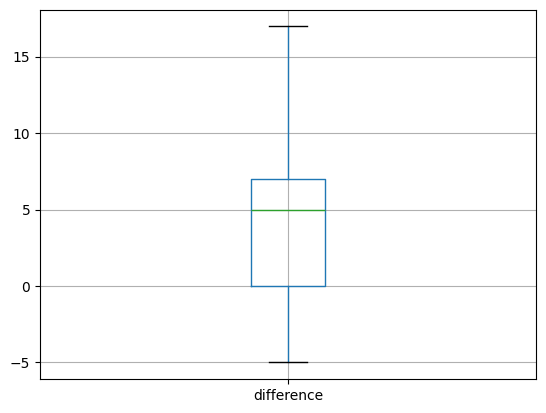

In [ ]:
diff_no_outliers_df.boxplot("difference")

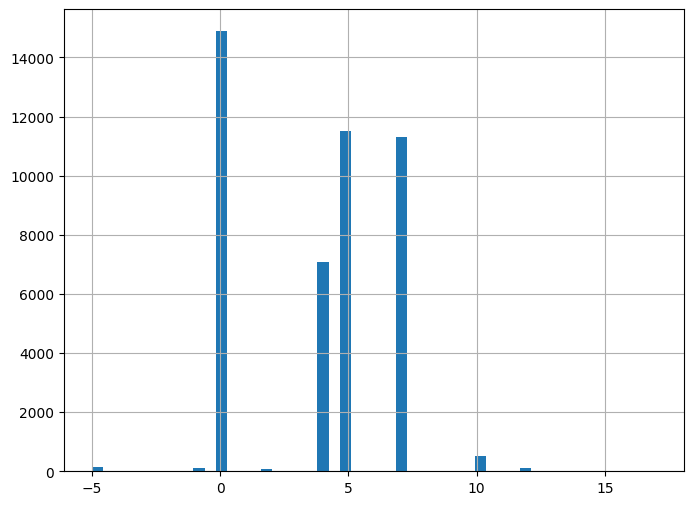

In [ ]:
diff_no_outliers_df.difference.hist(bins= 50, figsize=(8,6));

In [ ]:
diff_no_outliers_df.difference.describe()

,difference
count,45803.00
mean,3.74
std,2.92
min,-5.00
25%,0.00
50%,4.99
75%,6.99
max,16.97


In [ ]:
diff_no_outliers_df.difference.value_counts().sort_values(ascending=False).head(10)

,count
difference,
0.00,13328
6.99,5040
4.99,3531
4.99,2575
4.99,2395
3.99,1935
6.99,1925
3.99,1659
3.99,1502


In [ ]:
#just to check/show that those values are different
diff_no_outliers_df.difference.astype(str).value_counts().sort_values(ascending=False).head(10)

,count
difference,
0.0,13328
6.990000000000009,5040
4.990000000000009,3531
4.990000000000002,2575
4.989999999999995,2395
3.990000000000009,1935
6.989999999999995,1925
3.990000000000002,1659
3.989999999999995,1502


This looks much more like what we would expect: a small difference, but nothing extreme.

Now we need to remove these orders with extreme differences from our orders and orderlines DataFrames.

In [ ]:
normal_diff_list = diff_no_outliers_df['order_id']

In [ ]:
orders_qa = orders_qa.loc[orders_qa["order_id"].isin(normal_diff_list), :]

In [ ]:
orderlines_qa = orderlines_qa.loc[orderlines_qa["id_order"].isin(normal_diff_list), :]

In [ ]:
orders_qa["order_id"].nunique(), orderlines_qa["id_order"].nunique()

(45803, 45803)

In [ ]:
(orders_qa["order_id"].nunique()) == (orderlines_qa["id_order"].nunique())

True

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

Happy with what i have till now :)

Do not forget to download your quality controlled DataFrames

In [ ]:
# from google.colab import files

# orders_qa.to_csv("orders_qa.csv", index=False)
# files.download("orders_qa.csv")

# orderlines_qa.to_csv("orderlines_qa.csv", index=False)
# files.download("orderlines_qa.csv")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# orders_qa.to_csv("/content/drive/MyDrive/orders_qa.csv", index=False)
# orderlines_qa.to_csv("/content/drive/MyDrive/orderlines_qa.csv", index=False)
# products_qa.to_csv("/content/drive/MyDrive/products_qa.csv", index=False)

Let's find the discounts.

In [ ]:
# Start with orderlines
merge_all= orderlines_qa.copy()

# Merge orders
merge_all = merge_all.merge(orders_qa,left_on='id_order',right_on='order_id',how='left')

# Merge products
merge_all = merge_all.merge(products_qa,on='sku',how='left')

# Extract brand code from SKU
merge_all['brand_code'] = merge_all['sku'].str[:3]

# Merge brands
# url = "https://drive.google.com/file/d/1_JJj8BVRWyXVUZyA4CSyooWqKKdaAUKc/view?usp=sharing"
# path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
# brands= pd.read_csv(path)
# merge_all = merge_all.merge(brands,left_on='brand_code',right_on='short',how='left')

In [ ]:
merge_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60896 entries, 0 to 60895
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                60896 non-null  int64         
 1   id_order          60896 non-null  int64         
 2   product_quantity  60896 non-null  int64         
 3   sku               60896 non-null  object        
 4   unit_price        60896 non-null  float64       
 5   date              60896 non-null  object        
 6   order_id          60896 non-null  int64         
 7   created_date      60896 non-null  datetime64[ns]
 8   total_paid        60896 non-null  float64       
 9   state             60896 non-null  object        
 10  name              59254 non-null  object        
 11  desc              59254 non-null  object        
 12  price             59254 non-null  float64       
 13  in_stock          59254 non-null  float64       
 14  type              5924

In [ ]:
# missing sku in products table
missing_sku = merge_all[merge_all['price'].isna()]['sku'].unique()
len(missing_sku)


249

In [ ]:
merge_all['discount']=merge_all['price']-merge_all['unit_price']
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,name,desc,price,in_stock,type,brand_code,discount
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,Kit temperature sensor for HDD iMac 21 inch and 27 inch 2011.,60.99,1.00,12755395,OWC,13.50
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s / 5c / 4S,22.95,0.00,5720,IOT,3.96
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",Apple MagSafe 2 Charger for MacBook Pro 15-inch Retina 85W unboxed,89.00,1.00,13005399,APP,16.81
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",IMac desktop computer 27 inch Retina 5K RAM 32GB 2TB Drive Fusion (MK462Y / A).,3209.00,0.00,1282,PAC,643.01
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with 555MB for Mac and PC.,76.99,0.00,1298,CRU,16.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01


In [ ]:
merge_all['discount_total']= merge_all['discount']* merge_all['product_quantity']
merge_all

,id,id_order,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,name,desc,price,in_stock,type,brand_code,discount,discount_total
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,299545,2017-01-01 01:51:47,51.48,Completed,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,Kit temperature sensor for HDD iMac 21 inch and 27 inch 2011.,60.99,1.00,12755395,OWC,13.50,13.50
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,299546,2017-01-01 01:57:34,18.99,Completed,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s / 5c / 4S,22.95,0.00,5720,IOT,3.96,3.96
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,295347,2017-01-01 02:02:38,72.19,Completed,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",Apple MagSafe 2 Charger for MacBook Pro 15-inch Retina 85W unboxed,89.00,1.00,13005399,APP,16.81,16.81
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,299549,2017-01-02 10:00:20,2565.99,Completed,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",IMac desktop computer 27 inch Retina 5K RAM 32GB 2TB Drive Fusion (MK462Y / A).,3209.00,0.00,1282,PAC,643.01,643.01
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556,2017-01-01 02:30:08,65.89,Completed,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with 555MB for Mac and PC.,76.99,0.00,1298,CRU,16.09,16.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60891,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,527035,2018-03-14 11:44:34,37.98,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01,15.01
60892,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,527070,2018-03-14 11:50:48,24.97,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01,30.02
60893,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,527074,2018-03-14 11:51:42,24.97,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01,30.02
60894,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,527096,2018-03-14 11:58:40,34.96,Completed,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,APP,15.01,45.03
